Music Playlist Data Analysis Project using Python

Project Type: Data Analyst / Exploratory Data Analysis  
Tools Used: Python, Pandas, NumPy, Matplotlib, Jupyter Notebook  
Dataset:`Music_playlist.csv`

Business Objective

Analyze music playlist data to understand song popularity, top genres, top artists, audio features, explicit song distribution, and relationships between music attributes such as danceability, energy, tempo, and popularity.


 ## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print('Libraries imported successfully')

Libraries imported successfully


## 2. Load the Dataset

In [15]:
# Load dataset

df = pd.read_csv("Music_playlist.csv")

print('Dataset loaded successfully')
print('Rows and Columns:', df.shape)
df.head()

Dataset loaded successfully
Rows and Columns: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Dataset Overview

In [16]:
# Basic dataset information
print('Dataset Shape:', df.shape)
print('Column Names:')
print(df.columns.tolist())

print('Dataset Info:')
df.info()

Dataset Shape: (114000, 21)
Column Names:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  

In [5]:
# Statistical summary of numerical columns
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 4. Data Cleaning

In [17]:
# Check missing values
missing_values = df.isnull().sum()
missing_values

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [18]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()
print('Duplicate Rows:', duplicate_rows)

Duplicate Rows: 0


In [19]:
# Remove unnecessary column if available
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Drop rows with missing values
df = df.dropna()

# Convert duration from milliseconds to minutes
df['duration_min'] = df['duration_ms'] / 60000

print('Data cleaning completed')
print('New Shape:', df.shape)
df.head()

Data cleaning completed
New Shape: (113999, 21)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


## 5. Key Performance Indicators

In [22]:
total_songs = len(df)
unique_tracks = df['track_id'].nunique()
unique_artists = df['artists'].nunique()
unique_genres = df['track_genre'].nunique()
avg_popularity = round(df['popularity'].mean(), 2)
avg_duration = round(df['duration_min'].mean(), 2)

print('Total Songs:', total_songs)
print('Unique Tracks:', unique_tracks)
print('Unique Artists:', unique_artists)
print('Unique Genres:', unique_genres)
print('Average Popularity:', avg_popularity)
print('Average Duration in Minutes:', avg_duration)

Total Songs: 113999
Unique Tracks: 89740
Unique Artists: 31437
Unique Genres: 114
Average Popularity: 33.24
Average Duration in Minutes: 3.8


## 6. Top 10 Artists by Number of Songs

In [23]:
top_artists = df['artists'].value_counts().head(10)
top_artists

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

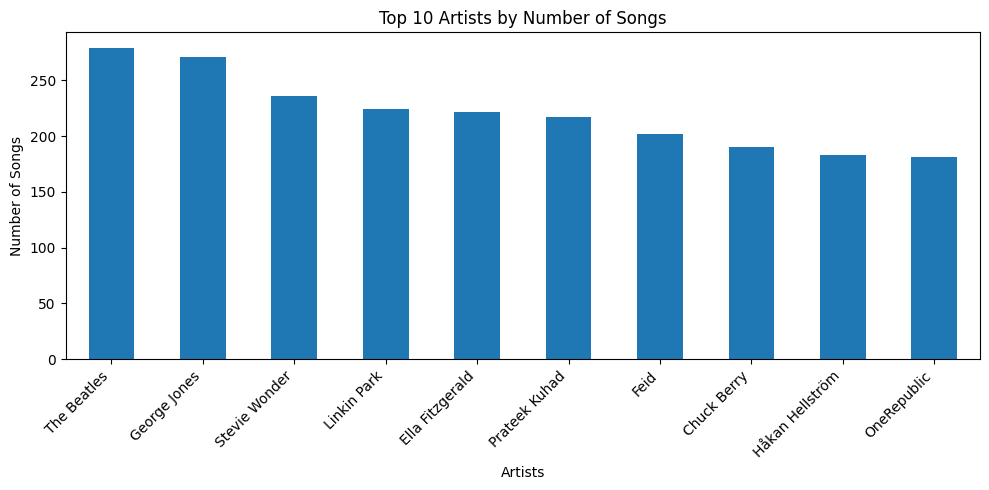

In [30]:
plt.figure(figsize=(10, 5))
top_artists.plot(kind='bar')
plt.title('Top 10 Artists by Number of Songs')
plt.xlabel('Artists')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Top 10 Music Genres

In [31]:
top_genres = df['track_genre'].value_counts().head(10)
top_genres

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar')
plt.title('Top 10 Music Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Top 10 Most Popular Songs

In [32]:
top_popular_songs = df[['track_name', 'artists', 'album_name', 'popularity', 'track_genre']].sort_values(
    by='popularity', ascending=False
).head(10)

top_popular_songs

,track_name,artists,album_name,popularity,track_genre
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,Unholy (feat. Kim Petras),100,dance
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,Unholy (feat. Kim Petras),100,pop
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52",99,hip-hop
88410,La Bachata,Manuel Turizo,La Bachata,98,reggae
30003,I'm Good (Blue),David Guetta;Bebe Rexha,I'm Good (Blue),98,edm
68303,La Bachata,Manuel Turizo,La Bachata,98,latino
89411,La Bachata,Manuel Turizo,La Bachata,98,reggaeton
81210,I'm Good (Blue),David Guetta;Bebe Rexha,I'm Good (Blue),98,pop
67356,La Bachata,Manuel Turizo,La Bachata,98,latin
20008,I'm Good (Blue),David Guetta;Bebe Rexha,I'm Good (Blue),98,dance


## 9. Top Genres by Average Popularity

In [33]:
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
genre_popularity

track_genre
pop-film     59.283000
k-pop        56.952953
chill        53.651000
sad          52.379000
grunge       49.594000
indian       49.539000
anime        48.772000
emo          48.128000
sertanejo    47.866000
pop          47.576000
Name: popularity, dtype: float64

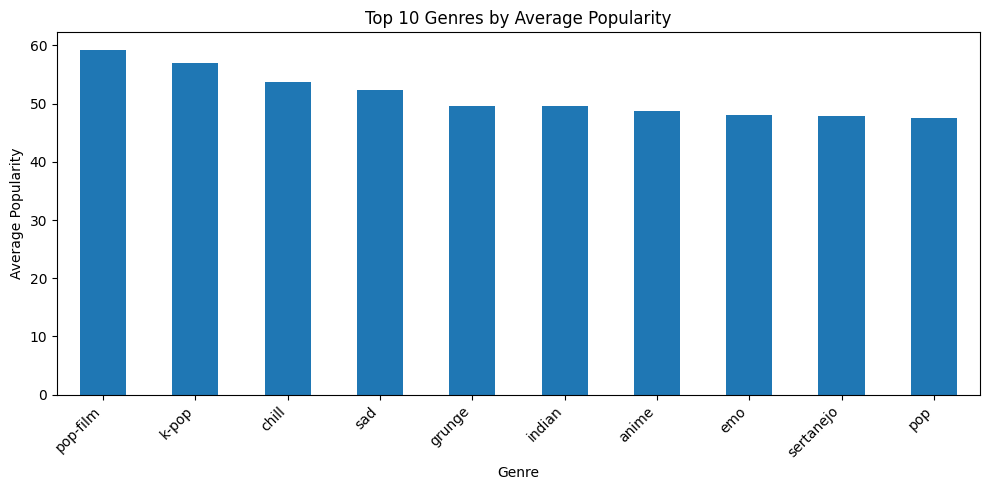

In [34]:
plt.figure(figsize=(10, 5))
genre_popularity.plot(kind='bar')
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Explicit vs Non-Explicit Songs

In [35]:
explicit_count = df['explicit'].value_counts()
explicit_count

explicit
False    104252
True       9747
Name: count, dtype: int64

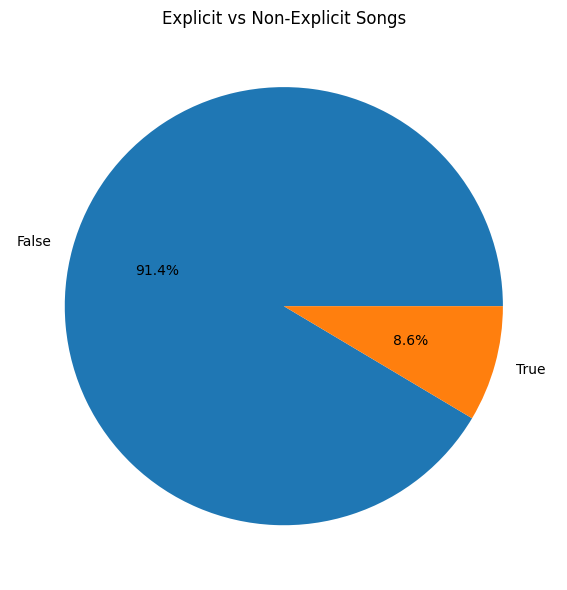

In [36]:
plt.figure(figsize=(6, 6))
explicit_count.plot(kind='pie', autopct='%1.1f%%')
plt.title('Explicit vs Non-Explicit Songs')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 11. Popularity Distribution

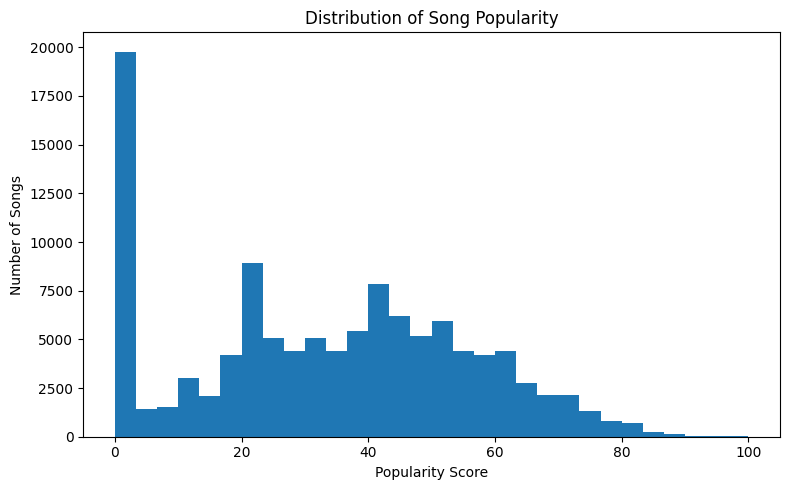

In [37]:
plt.figure(figsize=(8, 5))
plt.hist(df['popularity'], bins=30)
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

## 12. Relationship Between Audio Features and Popularity

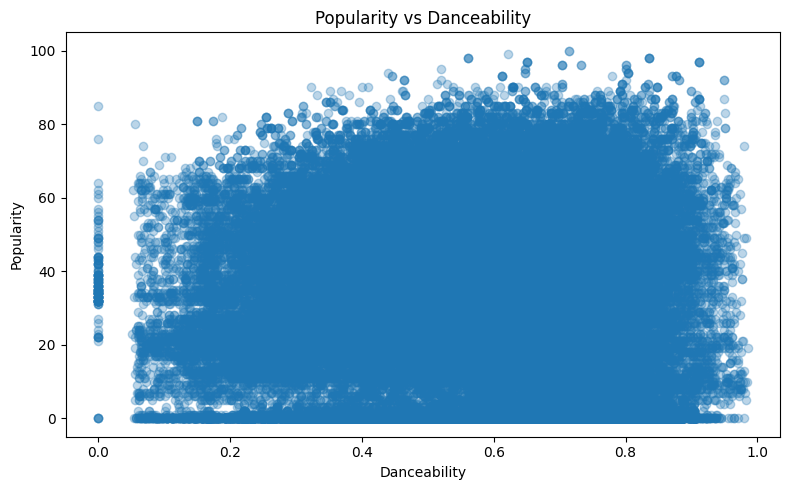

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(df['danceability'], df['popularity'], alpha=0.3)
plt.title('Popularity vs Danceability')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

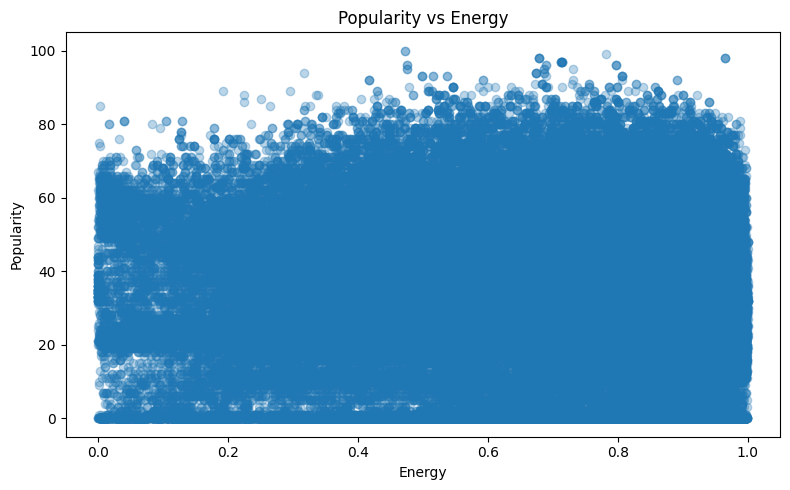

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(df['energy'], df['popularity'], alpha=0.3)
plt.title('Popularity vs Energy')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

## 13. Correlation Analysis

In [40]:
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

correlation = df[numeric_cols].corr()
correlation

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,0.035444,0.001053,0.050420,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,-0.007129
danceability,0.035444,1.000000,0.134325,0.259076,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,-0.073435
energy,0.001053,0.134325,1.000000,0.761690,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.058520
loudness,0.050420,0.259076,0.761690,1.000000,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,-0.003475
speechiness,-0.044930,0.108625,0.142508,0.060826,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.062605
acousticness,-0.025458,-0.171531,-0.733908,-0.589804,-0.002184,1.000000,0.104033,-0.020693,-0.107081,-0.208231,-0.103770
instrumentalness,-0.095147,-0.185608,-0.181880,-0.433478,-0.089617,0.104033,1.000000,-0.079896,-0.324310,-0.050328,0.124364
liveness,-0.005397,-0.131620,0.184795,0.076897,0.205218,-0.020693,-0.079896,1.000000,0.019093,0.000603,0.010308
valence,-0.040522,0.477347,0.258937,0.279851,0.036637,-0.107081,-0.324310,0.019093,1.000000,0.078269,-0.154464
tempo,0.013212,-0.050448,0.247852,0.212447,0.017274,-0.208231,-0.050328,0.000603,0.078269,1.000000,0.024356


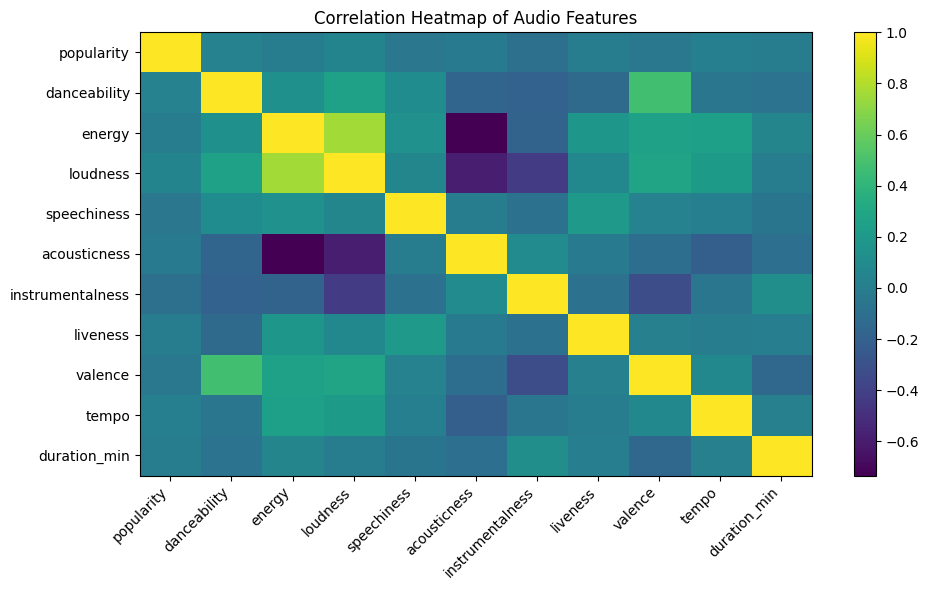

In [41]:
plt.figure(figsize=(10, 6))
plt.imshow(correlation, aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Heatmap of Audio Features')
plt.tight_layout()
plt.show()

## 14. Final Conclusions

The dataset contains a large collection of music tracks with different genres, artists, and audio features, making it suitable for exploratory data analysis.
Data cleaning revealed very few missing values and no major duplicate issues, which improved the reliability of analysis.
Some artists appeared significantly more frequently than others, showing dominance of popular artists in the playlist dataset.
Genres such as Pop, K-pop, Chill, and Sad music showed high popularity among listeners.
Songs with higher danceability and energy generally tended to have better popularity scores.

## Explanation
This project analyzes a music playlist dataset using Python. I cleaned the data by checking missing values, duplicate records, and unnecessary columns. Then I performed exploratory data analysis to find top artists, popular genres, most popular songs, explicit song distribution, and relationships between audio features and popularity. I used Pandas for data handling and Matplotlib for visualization.
